# Snapshot Exploration — Price & VWAP

Visualize price and VWAP for a specific ticker from ClickHouse `market_snapshot_collector`.

In [1]:
import os
from datetime import datetime
from zoneinfo import ZoneInfo

import clickhouse_connect
import matplotlib.pyplot as plt
import polars as pl

ET = ZoneInfo("America/New_York")

# --- ClickHouse Connection ---
ch_client = clickhouse_connect.get_client(
    host="localhost",
    port=8123,
    username="default",
    password=os.getenv("CLICKHOUSE_PASSWORD", ""),
    database="jerry_trader",
)
print("CH connected")

CH connected


In [2]:
# --- Parameters ---
DATE = "2026-03-13"
MODE = "replay"
TICKER = "EDHL"

In [3]:
query = """
    SELECT timestamp, price, vwap, volume, changePercent, rank
    FROM market_snapshot_collector FINAL
    WHERE date = {date:String}
      AND mode = {mode:String}
      AND ticker = {ticker:String}
    ORDER BY timestamp ASC
"""

result = ch_client.query(query, parameters={
    "date": DATE,
    "mode": MODE,
    "ticker": TICKER,
})

columns = list(result.column_names)
df = pl.DataFrame({col: [row[i] for row in result.result_rows] for i, col in enumerate(columns)})
print(f"{len(df)} rows, time range: {df['timestamp'].min()} - {df['timestamp'].max()}")
df.head()

2885 rows, time range: 1773389005000 - 1773408595000


timestamp,price,vwap,volume,changePercent,rank
i64,f64,f64,f64,f64,i64
1773389005000,3.46,3.46,13.0,-0.002888,77
1773389380000,3.66,3.474286,14.0,5.777292,12
1773390610000,3.67,3.669289,8214.0,6.066301,8
1773390635000,4.01,3.670601,8640.0,15.892606,7
1773390640000,4.22,3.699888,9000.0,21.961795,6


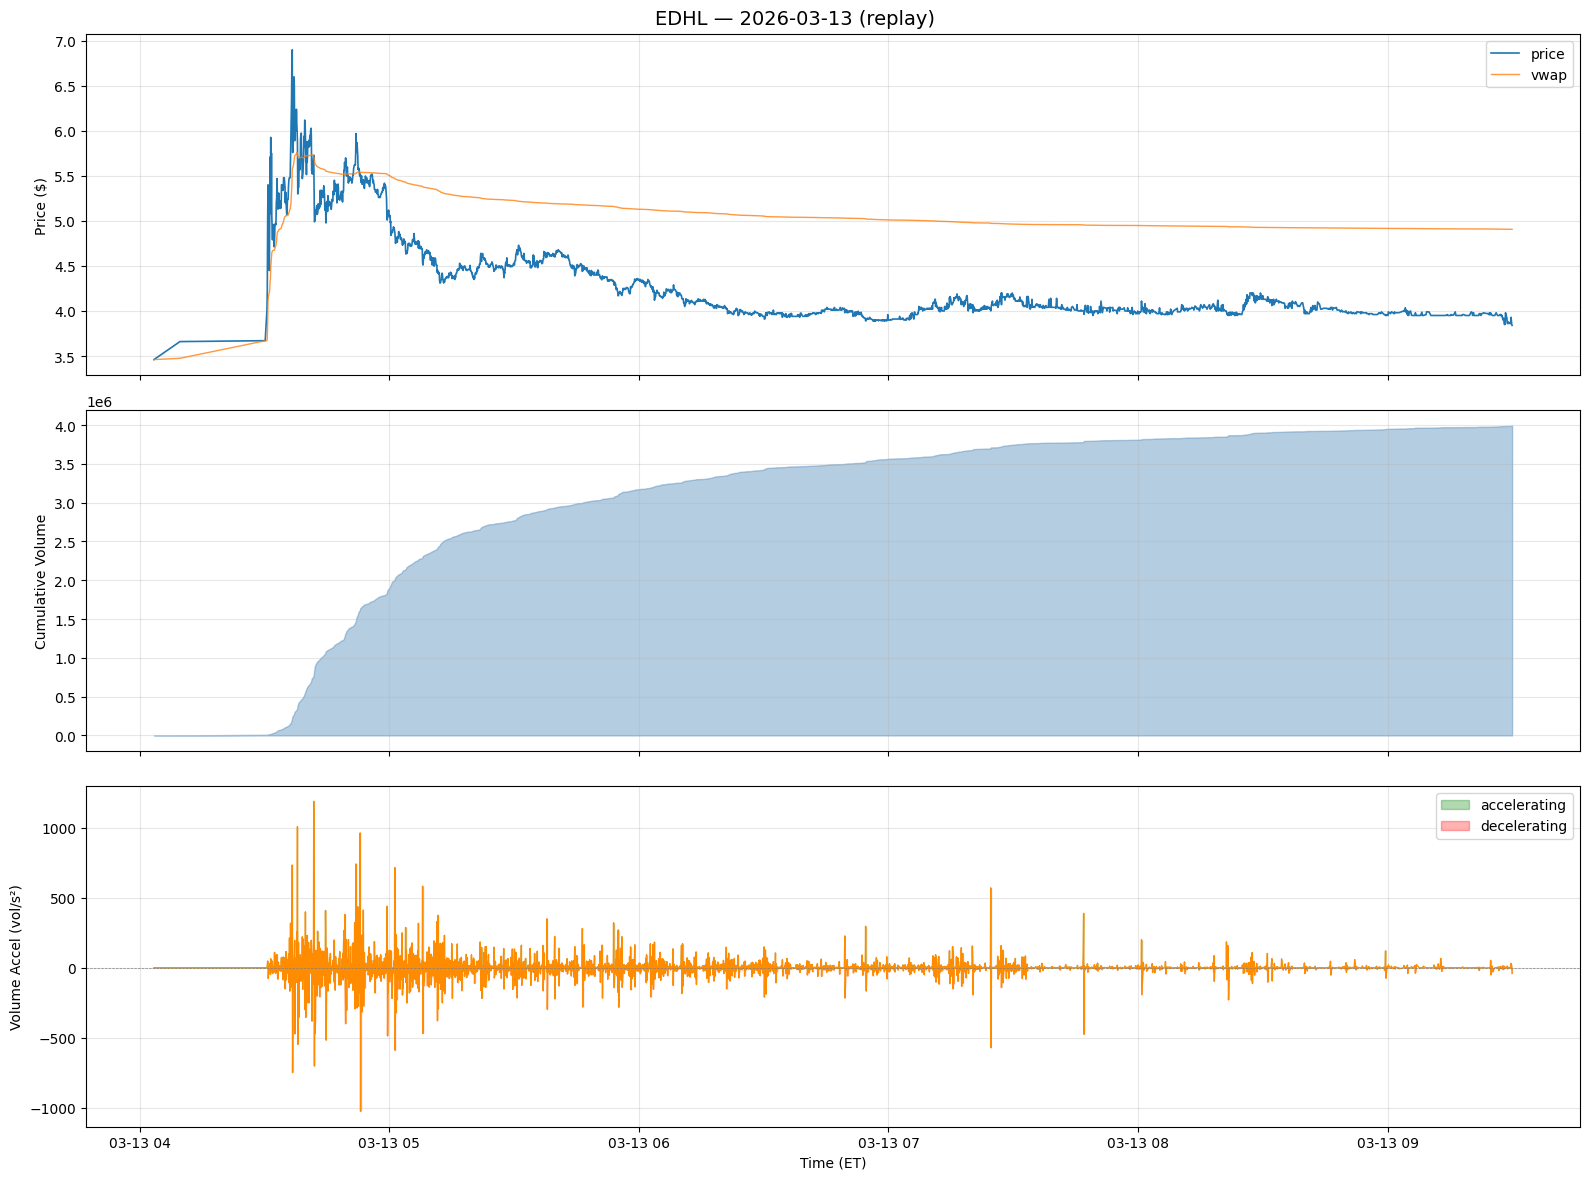

In [4]:
# Convert timestamp ms -> ET time string for x-axis
times = [datetime.fromtimestamp(t / 1000, tz=ET) for t in df["timestamp"].to_list()]

# Compute volume velocity (1st derivative) and acceleration (2nd derivative)
vol = df["volume"].cast(pl.Float64).to_list()
ts = df["timestamp"].to_list()

velocity = [0.0]
for i in range(1, len(vol)):
    dt = (ts[i] - ts[i - 1]) / 1000.0  # seconds
    velocity.append((vol[i] - vol[i - 1]) / dt if dt > 0 else 0.0)

acceleration = [0.0]
for i in range(1, len(velocity)):
    dt = (ts[i] - ts[i - 1]) / 1000.0
    acceleration.append((velocity[i] - velocity[i - 1]) / dt if dt > 0 else 0.0)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f"{TICKER} — {DATE} ({MODE})", fontsize=14)

# Price vs VWAP
ax1 = axes[0]
ax1.plot(times, df["price"], label="price", linewidth=1.2)
ax1.plot(times, df["vwap"], label="vwap", linewidth=1.0, alpha=0.8)
ax1.set_ylabel("Price ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cumulative Volume
ax2 = axes[1]
ax2.fill_between(times, vol, alpha=0.4, color="steelblue")
ax2.set_ylabel("Cumulative Volume")
ax2.grid(True, alpha=0.3)

# Volume Acceleration (2nd derivative)
ax3 = axes[2]
ax3.plot(times, acceleration, linewidth=1.0, color="darkorange")
ax3.axhline(y=0, color="gray", linestyle="--", linewidth=0.5)
ax3.fill_between(times, acceleration, where=[a >= 0 for a in acceleration], alpha=0.3, color="green", label="accelerating")
ax3.fill_between(times, acceleration, where=[a < 0 for a in acceleration], alpha=0.3, color="red", label="decelerating")
ax3.set_ylabel("Volume Accel (vol/s²)")
ax3.set_xlabel("Time (ET)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()